In [2]:
import data_functions as dfuncs
from importlib import reload
reload(dfuncs)


raw_data_path = "data/raw"
pbmc_4k_f = f"{raw_data_path}/pbmc_4k"
pbmc_8k_f = f"{raw_data_path}/pbmc_8k"

In [3]:
pbmc_4k_ad = dfuncs.convert_10x_to_anndata(pbmc_4k_f, 'PBMC 4k')
pbmc_8k_ad = dfuncs.convert_10x_to_anndata(pbmc_8k_f, 'PBMC 8k')

# Preprocessing and QC

In [4]:
# Perform QC on both datasets
pbmc_4k_qc = dfuncs.quality_control(pbmc_4k_ad)
pbmc_8k_qc = dfuncs.quality_control(pbmc_8k_ad)

: 

# Clustering and Cell Type Annotation

In [1]:
import scanpy as sc


def preprocess_and_cluster(adata, dataset_name):
    """Normalize, find HVGs, scale, perform PCA, compute neighbors, cluster, and UMAP"""
    print(f"\nProcessing {dataset_name}...")

    if "counts" not in adata.layers:
        adata.layers["counts"] = adata.X.copy()

    # Normalize and log-transform
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    
    # Find highly variable genes
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)
    
    # Scale and perform PCA
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, svd_solver='arpack')
    
    # Compute neighborhood graph
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    
    # Cluster with Leiden algorithm
    sc.tl.leiden(adata, resolution=0.5)
    
    # Compute UMAP
    sc.tl.umap(adata)
    
    print(f"✓ Found {len(adata.obs['leiden'].unique())} clusters")
    
    return adata

In [2]:
# Process both datasets
pbmc_4k_processed = preprocess_and_cluster(pbmc_4k_qc.copy(), "PBMC 4k")
pbmc_8k_processed = preprocess_and_cluster(pbmc_8k_qc.copy(), "PBMC 8k")

NameError: name 'pbmc_4k_qc' is not defined

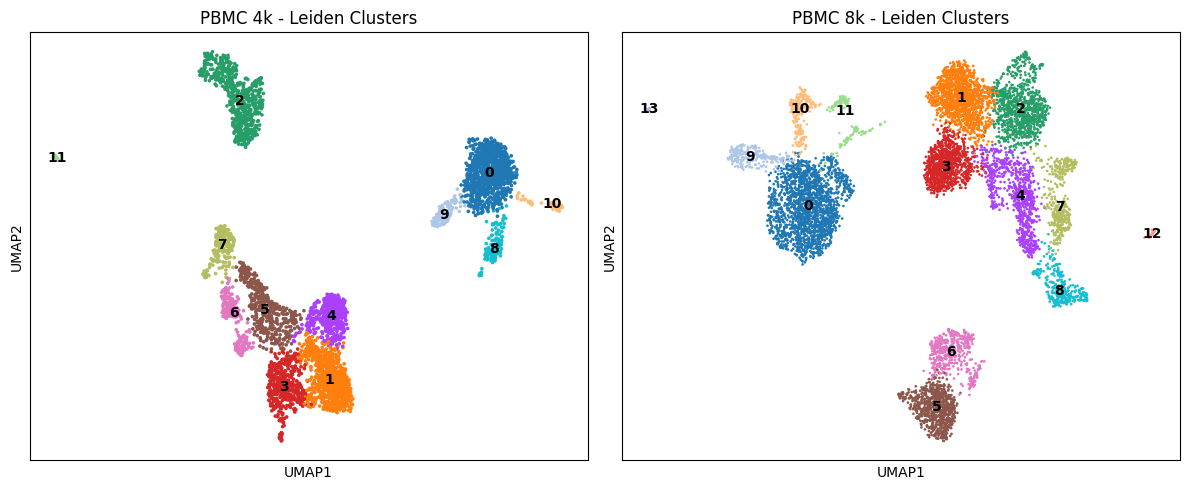

In [9]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.umap(pbmc_4k_processed, color=['leiden'], title='PBMC 4k - Leiden Clusters', ax=axes[0], show=False, legend_loc='on data')
sc.pl.umap(pbmc_8k_processed, color=['leiden'], title='PBMC 8k - Leiden Clusters', ax=axes[1], show=False, legend_loc='on data')
plt.tight_layout()
plt.show()

In [11]:
# Check available genes
print("Total genes in PBMC 4k:", pbmc_4k_processed.n_vars)
print("\nSample gene names:")
print(pbmc_4k_processed.var_names[:20])

Total genes in PBMC 4k: 2000

Sample gene names:
Index(['HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'FAM132A', 'RP5-902P8.12',
       'SCNN1D', 'MIB2', 'MMP23B', 'NPHP4', 'GPR153', 'UTS2', 'SPSB1', 'RBP7',
       'PGD', 'AGTRAP', 'TNFRSF1B', 'DHRS3', 'RP3-467K16.4', 'EFHD2'],
      dtype='object')


In [15]:
# Check marker genes for cell type identification
marker_genes_dict = {
    'B cell': ['CD79A', 'MS4A1', 'CD19'],
    'CD4+ T cell': ['CD3D', 'CD3E', 'CD4'],
    'CD8+ T cell': ['CD3D', 'CD3E', 'CD8A', 'CD8B'],
    'Natural killer cell': ['GNLY', 'NKG7'],
    'CD14+ monocyte': ['CD14', 'LYZ'],
    'CD16+ monocyte': ['FCGR3A', 'MS4A7'],
    'Dendritic cell': ['FCER1A', 'CST3'],
    'Plasmacytoid dendritic cell': ['IL3RA', 'GZMB', 'SERPINF1', 'ITM2C'],
    'Megakaryocyte': ['PPBP', 'PF4', 'GP9'],
}

# Filter marker genes to only include those present in the data
available_genes = pbmc_4k_processed.var_names
marker_genes = {}
for cell_type, genes in marker_genes_dict.items():
    available = [g for g in genes if g in available_genes]
    if available:
        marker_genes[cell_type] = available
        
print("Marker genes found in dataset:")
for ct, genes in marker_genes.items():
    print(f"{ct}: {genes}")

Marker genes found in dataset:
B cell: ['CD79A', 'MS4A1', 'CD19']
CD8+ T cell: ['CD8A', 'CD8B']
Natural killer cell: ['GNLY', 'NKG7']
CD14+ monocyte: ['CD14', 'LYZ']
CD16+ monocyte: ['FCGR3A', 'MS4A7']
Dendritic cell: ['FCER1A', 'CST3']
Plasmacytoid dendritic cell: ['IL3RA', 'GZMB', 'SERPINF1', 'ITM2C']
Megakaryocyte: ['PPBP', 'PF4', 'GP9']


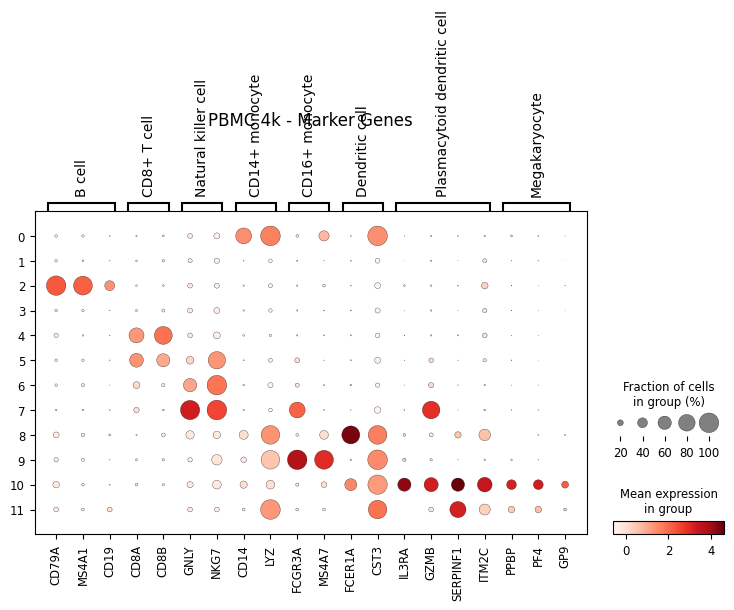

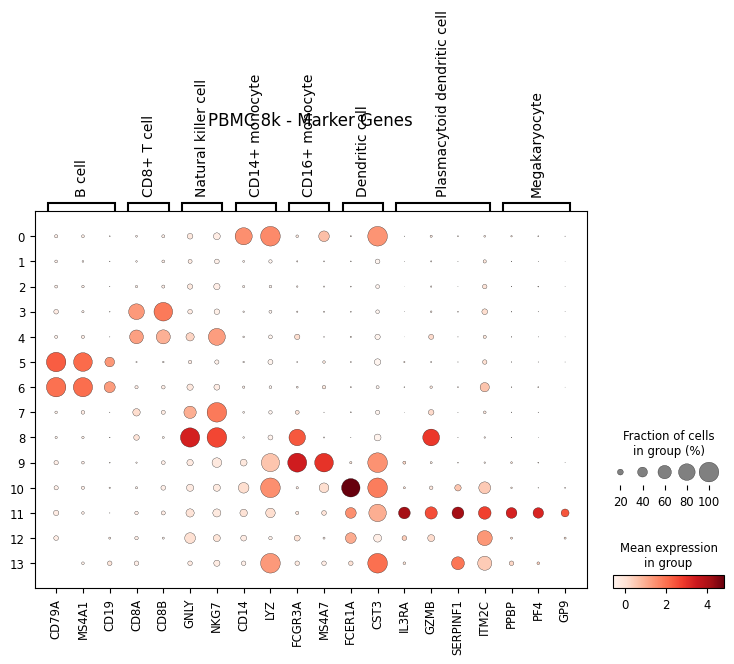

In [16]:
# Plot marker genes for PBMC 4k
if marker_genes:
    sc.pl.dotplot(pbmc_4k_processed, marker_genes, groupby='leiden', title='PBMC 4k - Marker Genes')
else:
    print("No marker genes found in dataset!")

# Plot marker genes for PBMC 8k
# Plot marker genes for PBMC 4k
if marker_genes:
    sc.pl.dotplot(pbmc_8k_processed, marker_genes, groupby='leiden', title='PBMC 8k - Marker Genes')
else:
    print("No marker genes found in dataset!")

In [21]:
# Function to assign annotations to clusters
def annotate_clusters(adata, cluster_to_celltype):
    """Assign cell types to clusters based on manual annotation"""
    adata.obs['celltype'] = adata.obs['leiden'].map(cluster_to_celltype).astype('category')
    return adata

# Manual annotation
pbmc_4k_annotation = {
    '0': 'CD14+ monocyte',
    '1': 'unknown', 
    '2': 'B cell',
    '3': 'CD8+ T cell',
    '4': 'CD8+ T cell',
    '5': 'CD8+ T cell',
    '6': 'Natural killer cell',
    '7': 'Natural killer cell',
    '8': 'Dendritic cell',
    '9': 'CD16+ monocyte',
    '10':'Plasmacytoid dendritic cell',
    '11':'Megakaryocyte',
}

pbmc_8k_annotation = {
    '0': 'CD14+ monocyte',
    '1': 'unknown', 
    '2': 'unknown',
    '3': 'CD8+ T cell',
    '4': 'CD8+ T cell',
    '5': 'B cell',
    '6': 'B cell',
    '7': 'Natural killer cell',
    '8': 'Natural killer cell',
    '9': 'CD16+ monocyte',
    '10':'Dendritic cell',
    '11':'Plasmacytoid dendritic cell',
    '12':'unknown',
    '13':'Megakaryocyte',
}

# Assign annotation to clusters
pbmc_4k_annotated = annotate_clusters(pbmc_4k_processed, pbmc_4k_annotation)
pbmc_8k_annotated = annotate_clusters(pbmc_8k_processed, pbmc_8k_annotation)

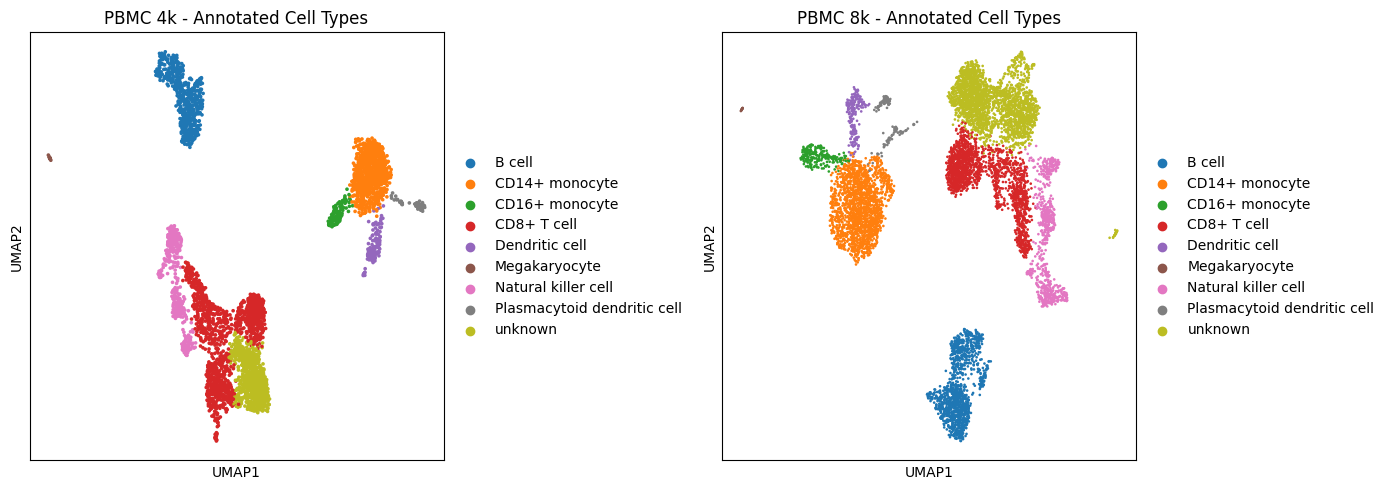

In [22]:
# Visualize annotated cell types side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(pbmc_4k_annotated, color=['celltype'], title='PBMC 4k - Annotated Cell Types', ax=axes[0], show=False)
sc.pl.umap(pbmc_8k_annotated, color=['celltype'], title='PBMC 8k - Annotated Cell Types', ax=axes[1], show=False)
plt.tight_layout()
plt.show()

# Clean up

In [27]:
# Remove CD4 T, CD8 T, NK, and unknown cells
cells_to_remove = ['CD4+ T cell', 'CD8+ T cell', 'Natural killer cell', 'unknown']
pbmc_4k_clean_ad = pbmc_4k_annotated[~pbmc_4k_annotated.obs['celltype'].isin(cells_to_remove)].copy()
pbmc_8k_clean_ad = pbmc_8k_annotated[~pbmc_8k_annotated.obs['celltype'].isin(cells_to_remove)].copy()

print(f"PBMC 4k: {pbmc_4k_annotated.n_obs} cells → {pbmc_4k_clean_ad.n_obs} cells after filtering")
print(f"PBMC 8k: {pbmc_8k_annotated.n_obs} cells → {pbmc_8k_clean_ad.n_obs} cells after filtering")
# Check remaining cell typs
print("\nPBMC 4k:", pbmc_4k_clean_ad.obs['celltype'].value_counts())
print("\nPBMC 8k:", pbmc_8k_clean_ad.obs['celltype'].value_counts())

PBMC 4k: 4327 cells → 1831 cells after filtering
PBMC 8k: 8371 cells → 3609 cells after filtering

PBMC 4k: celltype
CD14+ monocyte                 910
B cell                         611
Dendritic cell                 125
CD16+ monocyte                 116
Plasmacytoid dendritic cell     56
Megakaryocyte                   13
Name: count, dtype: int64

PBMC 8k: celltype
CD14+ monocyte                 1791
B cell                         1230
CD16+ monocyte                  243
Dendritic cell                  200
Plasmacytoid dendritic cell     131
Megakaryocyte                    14
Name: count, dtype: int64


# Export

In [29]:
# Export
dfuncs.save_h5ad(pbmc_4k_clean_ad, "pbmc_4k_clean_qc.h5ad")
dfuncs.save_h5ad(pbmc_8k_clean_ad, "pbmc_8k_clean_qc.h5ad")

Saved data/processed/pbmc_4k_clean_qc.h5ad
Saved data/processed/pbmc_8k_clean_qc.h5ad
Saved data/processed/pbmc_8k_clean_qc.h5ad
